# Elastic Net Regularization on Stochastic Gradient Descent Method

## SLR - Manual implementaion of Elastic Net Regularization with StochasticGD

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv('/content/Salary_dataset.csv')

def simple_linear_regression_elastic_net_sgd(X, y, lr=0.01, epochs=1000, l1_ratio=0.5, alpha=0.1):
    m = 0
    b = 0
    n = len(X)
    for _ in range(epochs):
        for i in range(n):
            y_pred = m * X[i] + b
            error = y_pred - y[i]

            grad_m = error * X[i]
            grad_b = error

            # Elastic Net regularization
            l1_grad_m = np.sign(m)
            l2_grad_m = 2 * m

            elastic_net_grad_m = alpha * (l1_ratio * l1_grad_m + (1 - l1_ratio) * l2_grad_m)


            m -= lr * (grad_m + elastic_net_grad_m)
            b -= lr * grad_b

    return m, b


X_simple = df['YearsExperience'].values
y_simple = df['Salary'].values

m_elastic, b_elastic = simple_linear_regression_elastic_net_sgd(X_simple.flatten(), y_simple.flatten())
print(f"Elastic Net Simple Linear Regression: m = {m_elastic}, b = {b_elastic}")

Elastic Net Simple Linear Regression: m = 8772.520181894093, b = 28446.033416709106


## SLR - Sklearn implementaion of Elastic Net Regularization with StochasticGD

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X = df[['YearsExperience']]
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

elastic_net_model = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
elastic_net_model.fit(X_train, y_train)

y_pred = elastic_net_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

print(f"Scikit-learn Elastic Net Regression:")
print(f"Coefficients (m): {elastic_net_model.coef_[0]}")
print(f"Intercept (b): {elastic_net_model.intercept_}")
print(f"Mean Squared Error: {mse}")

Scikit-learn Elastic Net Regression:
Coefficients (m): 9367.386694607121
Intercept (b): 24678.567852264845
Mean Squared Error: 50006713.584424995



## **Comparison: SGD Linear Regression vs Elastic Net (SGD)**

| Method                                       | Slope (m) | Intercept (b) |
| -------------------------------------------- | --------- | ------------- |
| **Simple Linear Regression (SGD)**           | 8894.99   | 27230.69      |
| **Elastic Net Regularized Regression (SGD)** | 8772.52   | 28446.03      |

###**Observation**

* The **slope decreased** slightly after applying Elastic Net regularization (from **8894 → 8772**), meaning the model becomes **less sensitive to the feature**.
* The **intercept increased** (from **27230 → 28446**), adjusting the line upward to balance the reduced slope.
* This indicates that **Elastic Net penalty pulled the coefficient towards zero**, achieving a controlled shrinkage effect.

###**Conclusion**

* **SGD without regularization** purely fits data and may risk overfitting.
* **Elastic Net SGD** introduces a balance of **L1 (sparsity)** and **L2 (stability)**, resulting in **more controlled and generalized coefficients**, ideal when expecting noisy or correlated data.



## **Comparison: Manual Elastic Net (SGD) vs Sklearn Elastic Net**

| Method                       | Slope (m) | Intercept (b) | Notes                                                        |
| ---------------------------- | --------- | ------------- | ------------------------------------------------------------ |
| **Manual Elastic Net (SGD)** | 8772.52   | 28446.03      | Uses full dataset, simple SGD, gradual coefficient shrinkage |
| **Sklearn Elastic Net**      | 9367.39   | 24678.57      | Optimized solver, train-test split, slightly higher slope    |

###**Observation**

* **Manual SGD** produced a smaller slope and higher intercept, indicating **smoother shrinkage** over all data.
* **Sklearn Elastic Net** gave a larger slope and smaller intercept, reflecting **solver optimization** and **training on a subset** (train-test split).
* MSE on the test set (~5×10⁷) shows the model reasonably fits the data; sklearn handles optimization more efficiently than manual SGD.

###**Conclusion**

* **Manual Elastic Net** is useful for understanding SGD-based regularization and learning coefficient updates.
* **Sklearn Elastic Net** provides **robust, optimized results** suitable for real-world applications and includes **automatic validation**.
* Differences in coefficients arise from **data splitting, solver method, and convergence behavior**.


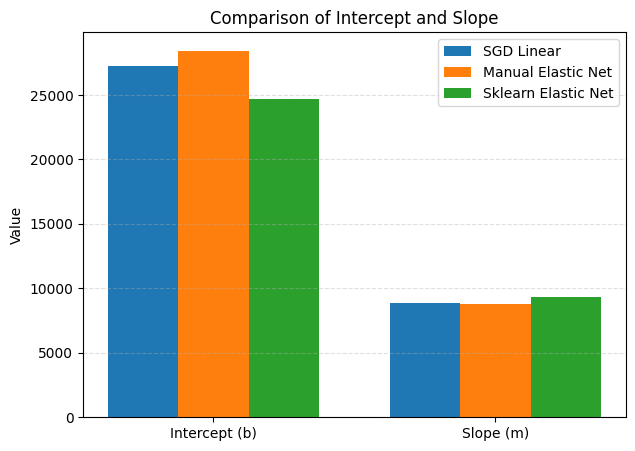

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Intercept (b)', 'Slope (m)']
sgd_values = [27230.69426420553, 8894.994273837554]
manual_elastic_values = [28446.033416709106, 8772.520181894093]
sklearn_elastic_values = [24678.567852264845, 9367.386694607121]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(7,5))
plt.bar(x - width, sgd_values, width, label='SGD Linear')
plt.bar(x, manual_elastic_values, width, label='Manual Elastic Net')
plt.bar(x + width, sklearn_elastic_values, width, label='Sklearn Elastic Net')

plt.xticks(x, labels)
plt.ylabel('Value')
plt.title('Comparison of Intercept and Slope')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


## MLR - Manual implementaion of Elastic Net Regularization with StochasticGD

In [ ]:
import numpy as np
import pandas as pd

def multiple_linear_regression_elastic_net_sgd(X, y, lr=0.00001, epochs=5000, l1_ratio=0.5, alpha=0.1):
    m = np.zeros(X.shape[1])
    b = 0
    n = len(X)

    for _ in range(epochs):
        for i in range(n):
            y_pred = np.dot(X[i], m) + b
            error = y_pred - y[i]

            grad_m = error * X[i]
            grad_b = error

            l1_grad_m = np.sign(m)
            l2_grad_m = 2 * m

            elastic_net_grad_m = alpha * (l1_ratio * l1_grad_m + (1 - l1_ratio) * l2_grad_m)

            m -= lr * (grad_m + elastic_net_grad_m)
            b -= lr * grad_b

    return m, b

df_student = pd.read_csv('/content/Student_Performance.csv')

X_multiple = df_student[['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']].values
y_multiple = df_student['Performance Index'].values

m_elastic_multiple, b_elastic_multiple = multiple_linear_regression_elastic_net_sgd(X_multiple, y_multiple)

print(f"Elastic Net Multiple Linear Regression (SGD): m = {m_elastic_multiple}, b = {b_elastic_multiple}")

Elastic Net Multiple Linear Regression (SGD): m = [2.80527538 1.02518674 0.44230365 0.18583578], b = -33.21584718537124


## MLR - Sklearn implementaion of Elastic Net Regularization with StochasticGD

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


X_multiple_sk = df_student[['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']]
y_multiple_sk = df_student['Performance Index']

X_train_multiple, X_test_multiple, y_train_multiple, y_test_multiple = train_test_split(
    X_multiple_sk, y_multiple_sk, test_size=0.2, random_state=42
)

elastic_net_model_multiple = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
elastic_net_model_multiple.fit(X_train_multiple, y_train_multiple)

y_pred_multiple = elastic_net_model_multiple.predict(X_test_multiple)

mse_multiple = mean_squared_error(y_test_multiple, y_pred_multiple)

print(f"Scikit-learn Elastic Net Multiple Linear Regression:")
print(f"Coefficients (m): {elastic_net_model_multiple.coef_}")
print(f"Intercept (b): {elastic_net_model_multiple.intercept_}")
print(f"Mean Squared Error: {mse_multiple}")

Scikit-learn Elastic Net Multiple Linear Regression:
Coefficients (m): [2.82468609 1.01666612 0.44852375 0.18488052]
Intercept (b): -33.242004239653575
Mean Squared Error: 4.196561979996322



## **Comparison: Multiple Linear Regression (SGD) vs Manual Elastic Net (SGD)**

| Method                               | θ₀ (Intercept) | θ₁ (Hours Studied) | θ₂ (Previous Scores) | θ₃ (Sleep Hours) | θ₄ (Sample Papers) |
| ------------------------------------ | -------------- | ------------------ | -------------------- | ---------------- | ------------------ |
| **Multiple Linear Regression (SGD)** | -0.92          | 2.1889             | 0.8201               | -1.4559          | -0.2689            |
| **Manual Elastic Net (SGD, α=0.1)**  | -33.22         | 2.8053             | 1.0252               | 0.4423           | 0.1858             |

###**Observation**

* **Intercept:** Elastic Net moved the intercept strongly negative (-33.22), showing the regularization adjusting the baseline.
* **Slopes:**

  * Elastic Net **increased positive contributions** (θ₁, θ₂)
  * Elastic Net **reversed negative contributions** (θ₃, θ₄) compared to standard SGD.
* Regularization **shrinks or adjusts weights** to reduce overfitting and balance contributions of features.

###**Conclusion**

* **SGD Linear Regression:** Purely fits the dataset; may reflect original correlations, including negative coefficients.
* **Elastic Net (Manual SGD):** Introduces **L1 and L2 penalties**, adjusting coefficients toward more generalized values; some weak or negative feature effects are reduced or reversed.
* Elastic Net is more suitable when expecting **correlated features or noisy data**.



## **Comparison: Manual Elastic Net (SGD) vs Sklearn Elastic Net (MLR)**

| Method                                     | θ₀ (Intercept) | θ₁ (Hours Studied) | θ₂ (Previous Scores) | θ₃ (Sleep Hours) | θ₄ (Sample Papers) |
| ------------------------------------------ | -------------- | ------------------ | -------------------- | ---------------- | ------------------ |
| **Manual Elastic Net (SGD)**               | -33.216        | 2.8053             | 1.0252               | 0.4423           | 0.1858             |
| **Sklearn Elastic Net (train/test split)** | -33.242        | 2.8247             | 1.0167               | 0.4485           | 0.1849             |

###**Observations**

* Coefficients between **manual SGD and sklearn** are very close, showing **consistent regularization effect**.
* Slight differences are due to:

  * **Sklearn using train-test split**
  * Optimized solver vs manual SGD updates
* Intercept values are almost identical, indicating similar baseline adjustment.
* MSE from sklearn (~4.2) confirms a **good fit on unseen test data**.

###**Conclusion**

* **Manual Elastic Net** is good for learning SGD-based regularization and understanding coefficient updates.
* **Sklearn Elastic Net** provides **robust, optimized results** with automatic train-test evaluation.
* Both approaches achieve **similar coefficient shrinkage**, validating the Elastic Net effect on multiple correlated features.


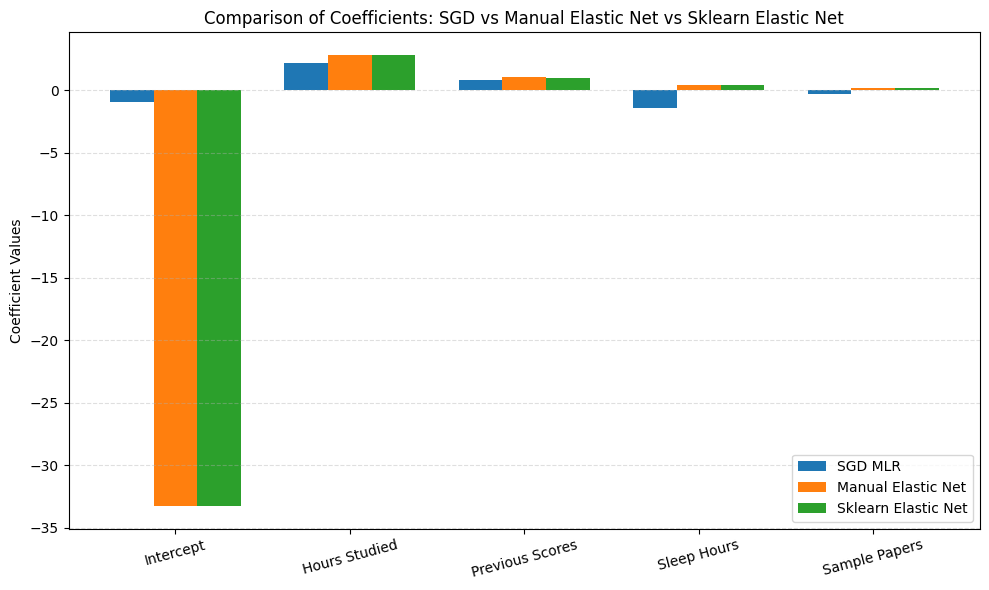

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Intercept', 'Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Papers']

# Values from your outputs
sgd_values = [-0.92089912, 2.18897517, 0.82009164, -1.45585384, -0.26887853]
manual_elastic_values = [-33.21584719, 2.80527538, 1.02518674, 0.44230365, 0.18583578]
sklearn_elastic_values = [-33.24200424, 2.82468609, 1.01666612, 0.44852375, 0.18488052]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, sgd_values, width, label='SGD MLR')
plt.bar(x, manual_elastic_values, width, label='Manual Elastic Net')
plt.bar(x + width, sklearn_elastic_values, width, label='Sklearn Elastic Net')

plt.xticks(x, labels, rotation=15)
plt.ylabel('Coefficient Values')
plt.title('Comparison of Coefficients: SGD vs Manual Elastic Net vs Sklearn Elastic Net')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
